# How uncertain is a fitted regression slope?

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/regression/02-testing-a-regression-slope.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

The first Regression notebook fitted a simple temperature–NOx line. Here,
**NOx** is the measured nitrogen-oxides concentration in the turbine exhaust
(mg/m³), and **AT** is ambient temperature (°C):

$$
\widehat{\mathrm{NOx}} = 80.80 - 0.875\,\mathrm{AT}.
$$

A hat denotes a quantity estimated from observed data. Thus,
$\widehat{\mathrm{NOx}}$ is the model's predicted NOx value, and the
number $-0.875$ is the fitted slope, $\hat{\beta}_1$. It is an estimate,
not a directly observed property of the gas-turbine population. This notebook
begins by asking why a fitted slope
would change if we had collected a different set of comparable observations.


## Learning objectives

- Distinguish the fixed, unknown population slope $\beta_1$ from its fitted
  estimate $\hat{\beta}_1$.
- See how fitted slopes vary across different subsets of observations.
- Explain why regression needs a principled measure of slope uncertainty.


## 1. One fitted line

We use the same hourly gas-turbine observations as before. The simple
population model is

$$
E[\mathrm{NOx}\mid\mathrm{AT}] = \beta_0 + \beta_1\mathrm{AT}.
$$

Read $E[\mathrm{NOx}\mid\mathrm{AT}]$ as **expected NOx given ambient
temperature**: the long-run average NOx across comparable operating hours at
a particular AT value. The vertical scatter around the line means that an
individual hourly observation need not equal that average.

The population slope $\beta_1$ is fixed but unknown. When we fit the line to
one collection of observations, we obtain the estimate $\hat{\beta}_1$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from urllib.request import urlretrieve

plt.style.use("seaborn-v0_8-whitegrid")

DATA_URL = "https://raw.githubusercontent.com/changyaochen/MECE4520/master/site/data/gas-turbine-course.csv"
candidates = [
    Path("../data/gas-turbine-course.csv"),
    Path("site/data/gas-turbine-course.csv"),
    Path("gas-turbine-course.csv"),
]
data_path = next((path for path in candidates if path.exists()), Path("gas-turbine-course.csv"))
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)

regression_data = pd.read_csv(data_path)[["AT", "NOX"]].dropna()
x = regression_data["AT"]
y = regression_data["NOX"]

full_model = sm.OLS(y, sm.add_constant(x)).fit()
full_intercept = full_model.params["const"]
full_slope = full_model.params["AT"]

pd.Series({
    "observations": len(regression_data),
    "fitted intercept, β̂₀ (mg/m³)": full_intercept,
    "fitted slope, β̂₁ (mg/m³ per °C)": full_slope,
})


observations                        36733.000000
fitted intercept, β̂₀ (mg/m³)          80.796532
fitted slope, β̂₁ (mg/m³ per °C)       -0.875273
dtype: float64

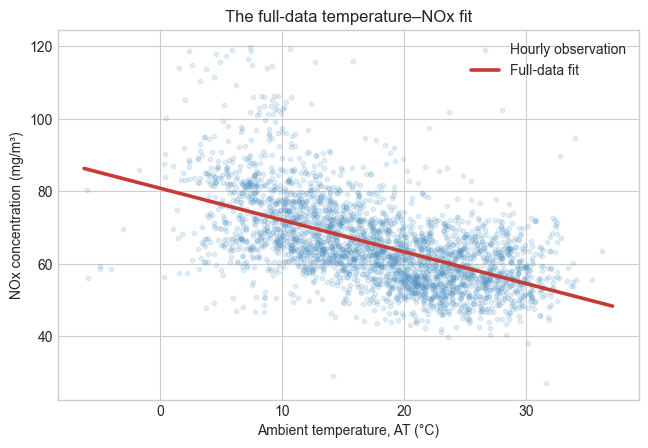

In [2]:
plot_data = regression_data.sample(n=3_000, random_state=4520)
temperature_grid = np.linspace(x.min(), x.max(), 200)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(plot_data["AT"], plot_data["NOX"], alpha=0.15, s=10, color="#4a90c2", label="Hourly observation")
ax.plot(temperature_grid, full_intercept + full_slope * temperature_grid, color="#c43c35", linewidth=2.6, label="Full-data fit")
ax.set(
    xlabel="Ambient temperature, AT (°C)",
    ylabel="NOx concentration (mg/m³)",
    title="The full-data temperature–NOx fit",
)
ax.legend()
plt.show()


## 2. Visualize repeated sampling

To make sampling variability visible, imagine fitting the line to a random
subset of operating hours. The fitted line would depend somewhat on which
hours happened to be included.

Below, we draw 1,000 random subsets containing 300 rows each, without
replacement, and fit a line to each. The left panel overlays 100 of those
fits so their spread remains easy to see; the right panel uses all 1,000.


In [3]:
n_trials = 1_000
n_lines_to_show = 100
sample_size = 300
rng = np.random.default_rng(4520)

def fit_line(frame):
    fitted = sm.OLS(frame["NOX"], sm.add_constant(frame["AT"])).fit()
    return pd.Series({
        "intercept": fitted.params["const"],
        "slope": fitted.params["AT"],
    })

sample_fits = []
for trial in range(n_trials):
    row_indices = rng.choice(len(regression_data), size=sample_size, replace=False)
    sample_fits.append(fit_line(regression_data.iloc[row_indices]))

sample_fits = pd.DataFrame(sample_fits)
sample_fits["trial"] = np.arange(1, n_trials + 1)
sample_fits[["intercept", "slope"]].describe().loc[["mean", "std", "min", "max"]]


,intercept,slope
mean,80.844189,-0.877377
std,1.835282,0.087955
min,74.886120,-1.315411
max,88.870334,-0.571029


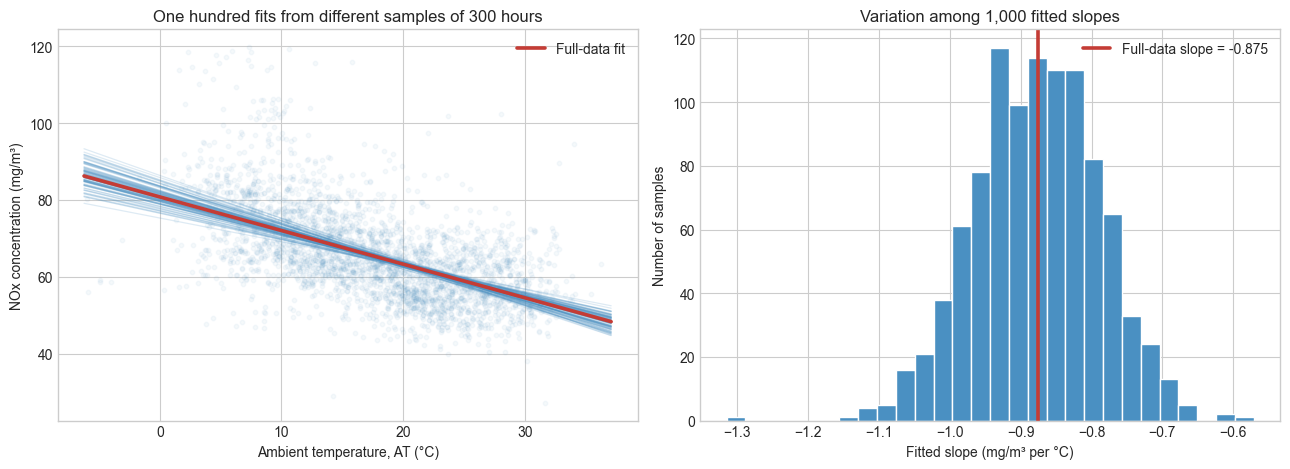

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].scatter(plot_data["AT"], plot_data["NOX"], alpha=0.05, s=10, color="#4a90c2")
for _, fit in sample_fits.iloc[:n_lines_to_show].iterrows():
    axes[0].plot(temperature_grid, fit["intercept"] + fit["slope"] * temperature_grid, color="#4a90c2", alpha=0.18, linewidth=0.9)
axes[0].plot(temperature_grid, full_intercept + full_slope * temperature_grid, color="#c43c35", linewidth=2.6, label="Full-data fit")
axes[0].set(
    xlabel="Ambient temperature, AT (°C)",
    ylabel="NOx concentration (mg/m³)",
    title="One hundred fits from different samples of 300 hours",
)
axes[0].legend()

axes[1].hist(sample_fits["slope"], bins=28, color="#4a90c2", edgecolor="white")
axes[1].axvline(full_slope, color="#c43c35", linewidth=2.6, label=f"Full-data slope = {full_slope:.3f}")
axes[1].set(
    xlabel="Fitted slope (mg/m³ per °C)",
    ylabel="Number of samples",
    title="Variation among 1,000 fitted slopes",
)
axes[1].legend()

fig.tight_layout()
plt.show()


The fitted lines are similar, but not identical. Their slopes differ because
each subset contains a different mix of operating hours and their associated
variation. This is why $\hat{\beta}_1$ is an estimate rather than the
unknown population value $\beta_1$.

The exercise is only a visual demonstration. To quantify uncertainty for the
full-data slope, we need a principled estimate of how much $\hat{\beta}_1$
would vary across comparable full-size datasets: its standard error.


## 3. Why the full-data slope is still an estimate

The 300-hour exercise was deliberately contrived: it gave us many
hypothetical datasets so that the variability in fitted slopes was visible. In practice,
we have one complete observed dataset. But it is still only one possible
set of turbine operating hours that could have been observed. If a
comparable observation process were repeated, the measured hours and their
emissions would differ, and so would $\hat{\beta}_1$.

Where does that dataset-to-dataset variability enter the model? For the
$i$th operating hour, write

$$
\mathrm{NOx}_i = \beta_0 + \beta_1 \mathrm{AT}_i + \epsilon_i.
$$

Here $\beta_0$ and $\beta_1$ are fixed but unknown features of the
underlying relationship. The error $\epsilon_i$ is the part of NOx for that
hour not explained by AT alone—for example, effects of other operating
conditions, unmeasured factors, and measurement variation. It changes from
one observed dataset to another; $\beta_1$ does not.

To quantify the resulting uncertainty, we condition on the observed
temperature values $x_i$ and assume the errors are independent, have mean
zero, and have a common variance $\sigma^2$. A rearrangement of the
ordinary-least-squares slope then gives

$$
\hat{\beta}_1 = \beta_1 +
\frac{\sum_{i=1}^{n}(x_i - \bar{x})\epsilon_i}{S_{xx}},
\qquad
S_{xx} = \sum_{i=1}^{n}(x_i - \bar{x})^2.
$$

The fitted slope is therefore the unknown population slope plus a weighted
sum of random errors. Under those assumptions,

$$
\operatorname{Var}(\hat{\beta}_1 \mid X)
= \frac{\sigma^2}{S_{xx}}.
$$

The denominator captures how much information the temperatures provide:
more observations and a wider spread of AT values both make $S_{xx}$ larger
and the fitted slope more precise.


We do not know the population error variance $\sigma^2$. We estimate it
from the residuals of the fitted line:

$$
e_i = y_i - \hat{y}_i,
\qquad
RSS = \sum_{i=1}^{n} e_i^2,
\qquad
s^2 = \frac{RSS}{n-2}.
$$

We divide by $n-2$ because the intercept and slope were estimated from the
same data. Replacing $\sigma$ with the residual estimate $s$ gives the
estimated standard error of the slope:

$$
SE(\hat{\beta}_1) = \frac{s}{\sqrt{S_{xx}}}.
$$


In [5]:
n = len(regression_data)
sxx = ((regression_data["AT"] - regression_data["AT"].mean()) ** 2).sum()
rss = (full_model.resid ** 2).sum()
residual_sd = np.sqrt(rss / (n - 2))
slope_se = residual_sd / np.sqrt(sxx)

pd.Series(
    {
        "Number of operating hours": n,
        "Residual standard deviation, s (mg/m³)": residual_sd,
        "Temperature spread, Sxx (°C²)": sxx,
        "Standard error of the slope": slope_se,
    }
).round(4)


Number of operating hours                 3.673300e+04
Residual standard deviation, s (mg/m³)    9.689900e+00
Temperature spread, Sxx (°C²)             2.037323e+06
Standard error of the slope               6.800000e-03
dtype: float64

## 4. A 95% confidence interval for the slope

With a standard error, we can put an interval around the fitted slope. For
simple linear regression, the usual 95% confidence interval is

$$
\hat{\beta}_1 \;\pm\; t^*_{n-2} SE(\hat{\beta}_1),
$$

where $t^*_{n-2}$ is the 97.5th percentile of a $t$ distribution with
$n-2$ degrees of freedom. This interval is exact when the model errors are
normally distributed. With a large dataset, it is commonly used as an
approximation when the errors are independent and reasonably well behaved.
The $t$ multiplier is very close to 1.96 here.


In [6]:
from scipy.stats import t

df = n - 2
t_star = t.ppf(0.975, df=df)
ci_lower = full_slope - t_star * slope_se
ci_upper = full_slope + t_star * slope_se

pd.Series(
    {
        "Fitted slope, β̂₁ (mg/m³ per °C)": full_slope,
        "Standard error": slope_se,
        "95% CI lower bound": ci_lower,
        "95% CI upper bound": ci_upper,
    }
).round(4)


Fitted slope, β̂₁ (mg/m³ per °C)   -0.8753
Standard error                      0.0068
95% CI lower bound                 -0.8886
95% CI upper bound                 -0.8620
dtype: float64

For this dataset, the interval gives a plausible range for the unknown
population slope under the model assumptions. Its frequentist interpretation
is about the procedure: if we repeatedly collected comparable datasets and
constructed intervals this way, about 95% of those intervals would contain
the fixed value $\beta_1$.

We have not yet tested a particular claim about $\beta_1$. That is the next
step.


## 5. Is the temperature slope statistically significant?

The full-data fit gave $\hat{\beta}_1 = -0.8753$ mg/m³ per °C. The
confidence interval says that this estimate is precise under the model. We
can now ask a specific population question: is there evidence that the
unknown slope $\beta_1$ differs from zero?

For a two-sided test, state the competing hypotheses as

$$
H_0: \beta_1 = 0
\qquad\text{versus}\qquad
H_A: \beta_1 \ne 0.
$$

Here $H_0$ says there is no **linear association** between AT and expected
NOx in this simple model. It does not say that temperature has no causal
effect on NOx.


### Standardize the fitted slope

The standard error tells us the scale of ordinary fitted-slope variation.
Under the null hypothesis, zero is the reference slope, so the test
statistic is

$$
t_{\mathrm{obs}} =
\frac{\hat{\beta}_1 - 0}{SE(\hat{\beta}_1)}.
$$

It measures how many standard errors the fitted slope is from zero. Under
$H_0$ and normally distributed model errors, this statistic follows a $t$
distribution with $n-2$ degrees of freedom; with this large dataset, that is
also the usual large-sample approximation.


In [7]:
from scipy.stats import t

alpha = 0.05
test_statistic = full_slope / slope_se
two_sided_p_value = 2 * t.sf(abs(test_statistic), df=df)
p_value_display = "< 0.001" if two_sided_p_value < 0.001 else f"{two_sided_p_value:.3f}"

pd.Series(
    {
        "Observed t statistic": test_statistic,
        "Two-sided p-value": p_value_display,
        "Decision at α = 0.05": "Reject H₀" if two_sided_p_value < alpha else "Fail to reject H₀",
    }
)


Observed t statistic   -128.929375
Two-sided p-value          < 0.001
Decision at α = 0.05     Reject H₀
dtype: object

For a two-sided test, the p-value is

$$
p = P\left(\lvert T \rvert \geq \lvert t_{\mathrm{obs}} \rvert
\;\middle|\; H_0\right).
$$

It is the probability of a fitted slope at least this far from zero, if the
population slope really were zero. It is **not** the probability that $H_0$
is true. We report $p < 0.001$, rather than a numerical zero.

> **Decision at $\alpha = 0.05$.** Since $p < 0.001 < 0.05$, we reject
> $H_0$. The fitted negative AT slope is **statistically significant at the
> 5% level** in this simple regression model.

This agrees with the 95% confidence interval: zero is outside
$[-0.8886, -0.8620]$. For matching two-sided $t$ tests and confidence
intervals, these are two ways of reaching the same decision.


## 6. What statistical significance does—and does not—say

Statistical significance says the observed negative slope would be hard to
reconcile with $\beta_1 = 0$ under this model. It does **not** establish
causality, validate this one-predictor model, or decide whether a change of
about $0.875$ mg/m³ per $1^\circ$C is engineering-important. Those require
domain knowledge, model checking, and—in a causal question—a defensible
study design.


## Check-in

1. In this model, what does $H_0: \beta_1 = 0$ claim?
2. What does the slope $t$ statistic measure?
3. Name one thing that $p < 0.001$ does **not** establish.

[Return to the Regression page](index.qmd)
